118 images × 39209 neurons
Computing observed mean LOO margin...
Observed mean LOO margin: 3.58777770159581
Running permutation test...
perm 1/200  stat=0.8902
perm 2/200  stat=1.3529
perm 3/200  stat=1.3164
perm 4/200  stat=0.6190
perm 5/200  stat=0.9038
perm 6/200  stat=0.8249
perm 7/200  stat=1.2291
perm 8/200  stat=0.0267
perm 9/200  stat=0.5526
perm 10/200  stat=0.0583
perm 11/200  stat=0.5337
perm 12/200  stat=0.9022
perm 13/200  stat=0.3907
perm 14/200  stat=0.4734
perm 15/200  stat=0.4743
perm 16/200  stat=-0.0377
perm 17/200  stat=0.7124
perm 18/200  stat=-0.0617
perm 19/200  stat=-0.1404
perm 20/200  stat=1.3095
perm 21/200  stat=0.4294
perm 22/200  stat=0.8311
perm 23/200  stat=0.2198
perm 24/200  stat=0.1610
perm 25/200  stat=0.3647
perm 26/200  stat=0.2616
perm 27/200  stat=0.1072
perm 28/200  stat=0.8881
perm 29/200  stat=-0.2956
perm 30/200  stat=1.5504
perm 31/200  stat=-0.3421
perm 32/200  stat=0.4868
perm 33/200  stat=1.1065
perm 34/200  stat=1.4625
perm 35/200  stat=

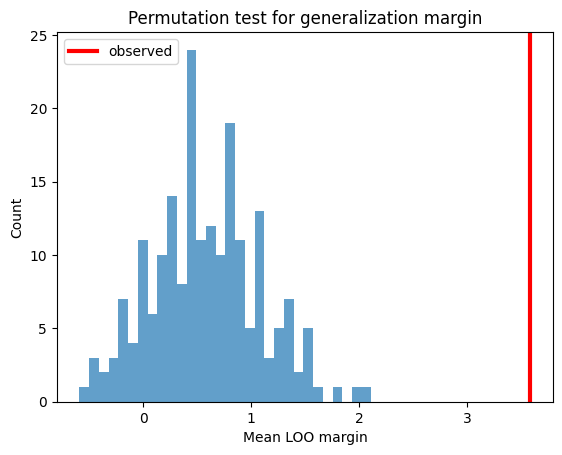

In [2]:
import numpy as np
import matplotlib.pyplot as plt

from joblib import Parallel, delayed
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression


"""
Variance geometry diagnostics for large neural populations
Animate vs Inanimate decoding (ImageNet labels)

LOO logistic regression fields
PCA of field variability
Safe for ~20k–40k neurons (no NxN covariance matrices)
"""

import numpy as np
import matplotlib.pyplot as plt

from joblib import Parallel, delayed
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression
from sklearn.decomposition import PCA

# ============================================================
# PATHS
# ============================================================

VIT_PATH    = '/home/maria/ProjectionSort/data/google_vit-base-patch16-224_embeddings_logits.pkl'
NEURAL_PATH = '/home/maria/ProjectionSort/data/hybrid_neural_responses_reduced.npy'
AREAS_PATH  = '/home/maria/ProjectionSort/data/brain_area.npy'

# ============================================================
# LOAD DATA
# ============================================================

vit   = np.load(VIT_PATH, allow_pickle=True)['natural_scenes']   # (images, 1000)
R     = np.load(NEURAL_PATH).T                                   # (images, neurons)
areas = np.load(AREAS_PATH, allow_pickle=True)

n_images, n_neurons = R.shape
print(f"{n_images} images × {n_neurons} neurons")

# ============================================================
# IMAGE-NET ANIMATE / INANIMATE LABEL
# ============================================================

top1 = np.argmax(vit, axis=1)
y = (top1 <= 397).astype(int)   # 1 = animate, 0 = inanimate

# ============================================================
# STANDARDIZE NEURAL DATA
# ============================================================

scaler = StandardScaler()
X = scaler.fit_transform(R)

# convert labels to {-1,1}
y_signed = np.where(y == 1, 1, -1)

n = X.shape[0]

# ============================================================
# FUNCTION: LOO margin for one index
# ============================================================

def loo_margin(j, X, y):

    mask = np.ones(len(y), dtype=bool)
    mask[j] = False

    X_train = X[mask]
    y_train = y[mask]

    X_test = X[j:j+1]
    y_test = y[j]

    model = LogisticRegression(
        penalty='l2',
        C=1.0,
        solver='liblinear',
        max_iter=1000
    )

    model.fit(X_train, y_train)

    beta = model.coef_.ravel()
    b = model.intercept_[0]

    norm_beta = np.linalg.norm(beta)

    decision = X_test @ beta + b

    margin = y_test * decision[0] / norm_beta

    return margin


# ============================================================
# FUNCTION: compute mean LOO margin
# ============================================================

def mean_loo_margin(X, y_signed):

    margins = Parallel(n_jobs=-1)(
        delayed(loo_margin)(j, X, y_signed)
        for j in range(len(y_signed))
    )

    margins = np.array(margins)

    return margins.mean(), margins


# ============================================================
# OBSERVED STATISTIC
# ============================================================

print("Computing observed mean LOO margin...")

obs_mean_margin, obs_margins = mean_loo_margin(X, y_signed)

print("Observed mean LOO margin:", obs_mean_margin)


# ============================================================
# PERMUTATION TEST
# ============================================================

n_perm = 200
perm_stats = []

print("Running permutation test...")

for b in range(n_perm):

    y_perm = np.random.permutation(y_signed)

    stat, _ = mean_loo_margin(X, y_perm)

    perm_stats.append(stat)

    print(f"perm {b+1}/{n_perm}  stat={stat:.4f}")

perm_stats = np.array(perm_stats)

# ============================================================
# P-VALUE
# ============================================================

p_value = (1 + np.sum(perm_stats >= obs_mean_margin)) / (n_perm + 1)

print("\nPermutation p-value:", p_value)


# ============================================================
# PLOT NULL DISTRIBUTION
# ============================================================

plt.hist(perm_stats, bins=30, alpha=0.7)
plt.axvline(obs_mean_margin, color='red', linewidth=3, label='observed')
plt.xlabel("Mean LOO margin")
plt.ylabel("Count")
plt.title("Permutation test for generalization margin")
plt.legend()
plt.show()